# Task 1: Collaborative Filtering (Memory-based vs Matrix Factorization)



**Methods**
- **A. Memory-based:** item-item kNN with adjusted-cosine similarity and item-mean-centered prediction.
- **B. Model-based:** biased matrix factorization, `r_hat = mu + b_u + b_i + p_u . q_i`, trained from scratch with SGD and L2 regularization.

Both methods use same train/test split, same metrics (RMSE, MAE for rating prediction; Precision@10, Recall@10, NDCG@10 for ranking)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split


,userID,item,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


**Dataset:** MovieLens 100K u.data file from (943 users, 1,682 movies, 100,000 explicit 1-5 ratings) from grouplens.org/datasets/movielens/100k/.

 i picked MovieLens 100K dtaset because it is a standard benchmark for
recommender-system research and is small enough to allow rapid experimentation
with different collaborative filtering approaches.

In [ ]:
df=pd.read_csv(r"/mnt/c/Users/saket/source/repos/nitk/u.data",sep="\t",names=["userID","item","rating","timestamp"])
df["userID"] -= 1   # 0-indexed
df["item"] -= 1
n_users, n_items = df.userID.max() + 1, df.item.max() + 1

df.head()

In [68]:

print(f"Number of ratings: {len(df):,}")
print(f"Number of users: {df['userID'].nunique():,}")
print(f"Number of movies: {df['item'].nunique():,}")


df.describe()

Number of ratings: 100,000
Number of users: 943
Number of movies: 1,682


,userID,item,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,461.48475,424.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,0.00000,0.000000,1.000000,8.747247e+08
25%,253.00000,174.000000,3.000000,8.794487e+08
50%,446.00000,321.000000,4.000000,8.828269e+08
75%,681.00000,630.000000,4.000000,8.882600e+08
max,942.00000,1681.000000,5.000000,8.932866e+08


In both methods we don't the timestamp column 

In [69]:
df=df.drop(columns="timestamp")

In [70]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
userID    0
item      0
rating    0
dtype: int64



Duplicate rows: 0


Sparsity: 93.695%


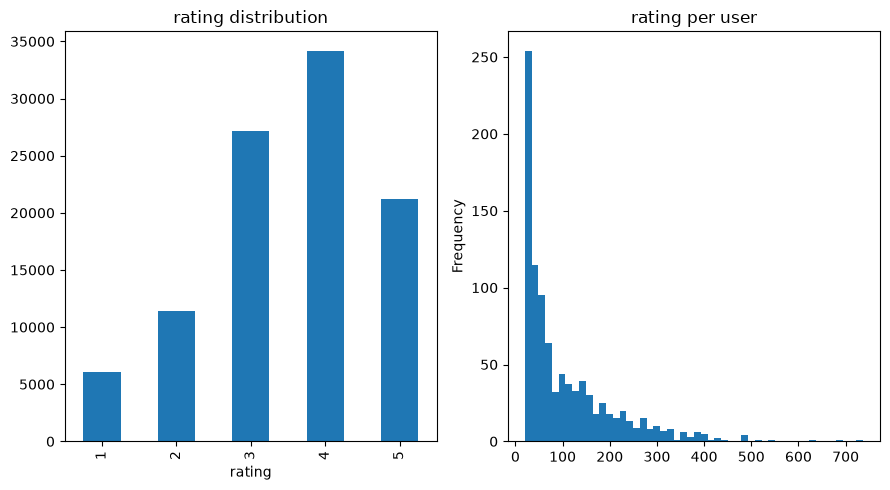

In [71]:
pivot_table=df.pivot(index="userID",columns="item",values="rating")
sparsity = pivot_table.isna().sum().sum() / pivot_table.size

print(f"Sparsity: {sparsity:.3%}")


fig,ax=plt.subplots(1,2,figsize=(9,5))
df.rating.value_counts().sort_index().plot.bar(ax=ax[0],title="rating distribution")
df.groupby("userID").size().plot.hist(bins=50,ax=ax[1],title="rating per user")
plt.tight_layout();plt.show()


## STEP2-TRAIN/VALIDATION/TEST SPLIT

I am splittindg the dataset into 80/20 train-test split then i am seperating the 10% of training data into development set

In [ ]:
train_pool,test_set=train_test_split(df,test_size=0.2,random_state=42)

train_set,dev_set=train_test_split(train_pool,test_size=0.1,random_state=42)

print(f"Train:{len(train_set)}")
print(f"Validation:{len(dev_set)}")
print(f"Test:{len(test_set)}")

Train:72000
Validation:8000
Test:20000


## STEP3- CREATING EVALUATION METRICES

I am using RMSE,MAE as predictive metrics on rating prediction and Precision@10, Recall@10, NDCG@10 as ranking metrics

In [ ]:

def build_matrix(data):
    r=np.zeros((n_users,n_items))
    r[data['userID'].values,data['item'].values]=data.rating.values
    return r

def RMSE(P,data):
    error=P[data['userID'].values,data['item'].values]-data.rating.values
    return float(np.sqrt(np.mean(error**2)))

def MAE(P,data):
    error=P[data['userID'].values,data['item'].values]-data.rating.values
    return float(np.mean(abs(error)))

def ranking_metrics(P, train_df, test_df, K=10, thr=4):
    scores = P.copy()
    scores[build_matrix(train_df) > 0] = -np.inf          
    rel = np.zeros((n_users, n_items), bool)
    t = test_df[test_df.rating >= thr]
    rel[t.userID.values, t.item.values] = True
    topk = np.argsort(-scores, axis=1)[:, :K]
    hits = np.take_along_axis(rel, topk, axis=1)
    n_rel = rel.sum(1)
    ok = n_rel > 0
    prec = (hits.sum(1) / K)[ok].mean()
    rec = (hits.sum(1) / np.maximum(n_rel, 1))[ok].mean()
    disc = 1 / np.log2(np.arange(2, K + 2))
    dcg = (hits * disc).sum(1)
    idcg = np.array([disc[:min(n, K)].sum() for n in n_rel])
    ndcg = (dcg / np.maximum(idcg, 1e-9))[ok].mean()
    return float(prec), float(rec), float(ndcg)

def evaluate(name, P, train_df, test_df, fit_time):
    r, m = RMSE(P, test_df),MAE(P,test_df)
    p, rc, n = ranking_metrics(P, train_df, test_df)
    return dict(Method=name, RMSE=r, MAE=m, **{"P@10": p, "R@10": rc, "NDCG@10": n}, **{"Fit time (s)": fit_time})

## METHOD-1:MEMORY BASED COLLABORATIVE FILTERING

For making the model i referred **Memory Based Collaborative Filtering with Lucene** paper.It eplains Adjusted cosine similarity and why to prefer it

In item-based CF, we compute similarity between items based on the ratings they have received from users. To accomplish this task, the k-Nearest-Neighbors (kNN) of a target item are retrieved from the historical rating profiles of other items. The recommendation is then made by aggregating the ratings given by the target user to these similar items.



In this work, we use **Adjusted Cosine Similarity (ACS)** as the similarity measure for the item-based collaborative filtering system. In the item-based approach, the similarity between two items is computed using the ratings provided by users who have rated both items. Like Pearson correlation, ACS considers only the co-rated users when computing the similarity. However, instead of computing the mean rating of an item only over these co-rated users, ACS uses the **global average rating of each user** across all items rated by that user. This is particularly useful because users may have different rating scales; some users tend to give consistently high ratings, while others tend to give lower ratings. By subtracting each user's global average rating, ACS reduces the effect of these individual rating biases and focuses on the relative preference of users for the two items. Furthermore, the global user averages can be precomputed and stored, making them readily available during similarity computation and avoiding the need to recompute co-rated averages at runtime. Therefore, ACS provides both bias-adjusted item similarity and an efficient way to support memory-based item-based CF.


$$
\text{sim}(i,j)=
\frac{\sum_{u\in U_{ij}}(r_{ui}-\bar r_u)(r_{uj}-\bar r_u)}
{\sqrt{\sum_{u\in U_{ij}}(r_{ui}-\bar r_u)^2}
\sqrt{\sum_{u\in U_{ij}}(r_{uj}-\bar r_u)^2}}
$$





For each item we select top k most similar positive neighours using ACS then we compute similarity-weighted average of user's rediduals on these neighbouring items.The prediction is calculated as item mean plus similarity-weighted average

$$
\boxed{
\hat{r}_{u,i}
=
\underbrace{\bar{r}_i}_{\text{Item-mean baseline}}
+
\underbrace{
\frac{
\sum\limits_{j \in N_k(i;u)}
s_{\mathrm{ACS}}(i,j)
\left(r_{u,j}-\bar{r}_j\right)
}{
\sum\limits_{j \in N_k(i;u)}
\left|s_{\mathrm{ACS}}(i,j)\right|
}
}_{\text{Similarity-weighted residual}}
}
$$



As the prediction is addition of item mean and similarity-weighted average we are creating a item mean baseline to evaluate the effectiveness 

The item-mean baseline provides a simple reference point by predicting a user's rating for an item using the average rating of that item in the training data. This baseline captures the general popularity or rating tendency of each item but does not account for the user's individual preferences or relationships between items. Establishing this baseline allows us to determine whether a more sophisticated collaborative filtering model provides a meaningful improvement.

$$
\boxed{
\text{Item-based kNN with ACS}
=
\text{Item-mean baseline}
+
\text{Similarity-weighted residual}
}
$$


We tune \(k\) on the validation set and select the value with the lowest RMSE.



In [74]:
def adjusted_cosine_similarity(R, M):
    gm = R[M].mean()
    user_means = np.where(M.sum(1) > 0,R.sum(1) / np.maximum(M.sum(1), 1),gm)

    R_centered = np.where( M,R - user_means[:, None],0.0)
    norms = np.linalg.norm(R_centered, axis=0) + 1e-9
    S = (R_centered.T @ R_centered) / np.outer(norms, norms)

    np.fill_diagonal(S, 0)

    return S


def item_mean_baseline(d):
    R = build_matrix(d)
    M = R > 0

    gm = R[M].mean()
    item_means = np.where(M.sum(0) > 0,R.sum(0) / np.maximum(M.sum(0), 1),gm)

    return np.tile(item_means,(n_users, 1))



In [ ]:

def item_knn(d, k=40):

    R = build_matrix(d)
    M = R > 0

    gm = R[M].mean()

    # Item means
    item_means = np.where(M.sum(0) > 0,R.sum(0) / np.maximum(M.sum(0), 1),gm)

    S = adjusted_cosine_similarity(R, M)

    Sk = np.zeros_like(S)   #similarity matrix
    
    # Top-k neighbours
    top = np.argpartition(-S,k,axis=1)[:, :k]
    rows = np.arange(n_items)[:, None]
    Sk[rows, top] = S[rows, top]

    # Ignore negative similarities
    Sk[Sk < 0] = 0

    # Item-centered residuals
    residuals = (M * (R - item_means[None, :]))
    
    numerator = residuals @ Sk.T
    denominator = (M.astype(float) @ Sk.T)
    adjustment = np.where(denominator > 1e-9,numerator / np.maximum(denominator, 1e-9),0.0)

    predictions = (item_means[None, :]+ adjustment)

    return np.clip(predictions, 1, 5)

k= 10 | RMSE=1.0297 | MAE=0.7985
k= 20 | RMSE=1.0158 | MAE=0.7828
k= 30 | RMSE=0.9977 | MAE=0.7683
k= 40 | RMSE=0.9807 | MAE=0.7584
k= 50 | RMSE=0.9710 | MAE=0.7526
k= 60 | RMSE=0.9632 | MAE=0.7474
k= 70 | RMSE=0.9555 | MAE=0.7415
k= 80 | RMSE=0.9445 | MAE=0.7342
k= 90 | RMSE=0.9405 | MAE=0.7319
k=100 | RMSE=0.9362 | MAE=0.7286
k=110 | RMSE=0.9312 | MAE=0.7257
k=120 | RMSE=0.9288 | MAE=0.7236
k=130 | RMSE=0.9255 | MAE=0.7226
k=140 | RMSE=0.9252 | MAE=0.7222
k=150 | RMSE=0.9229 | MAE=0.7211
best k: 150


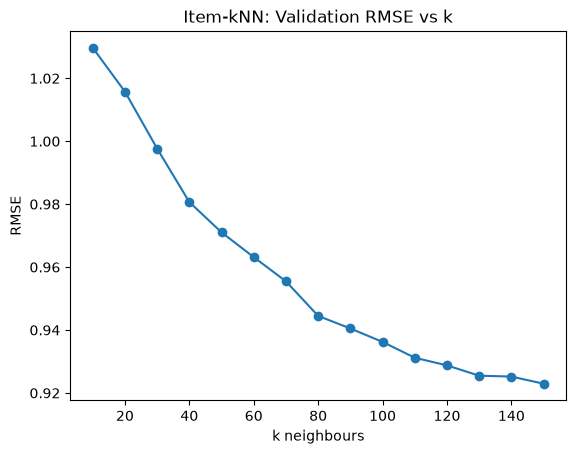

In [76]:
ks = np.arange(10,160,10)

knn_val = {}

for k in ks:

    predictions = item_knn(train_set, k)

    rmse = RMSE(predictions,dev_set)
    mae=MAE(predictions,dev_set)

    knn_val[k] = rmse

    print(
        f"k={k:3d} | "
        f"RMSE={rmse:.4f} | "
        f"MAE={mae:.4f}"
    )

best_k = min(knn_val,key=knn_val.get)
print("best k:", best_k)
plt.plot(ks, [knn_val[k] for k in ks], "o-")
plt.title("Item-kNN: Validation RMSE vs k")
plt.xlabel("k neighbours")
plt.ylabel("RMSE")
plt.show()


## Model-Based Collaborative Filtering

The implementation is based primarily on baised matrix factorization framework with L2 regularisation and SGD described in **Koren, Bell, Volinsky (2009), "Matrix Factorization Techniques for Recommender Systems** paper.


Memory-based methods such as user-based and item-based kNN directly use similarities between users or items to make predictions. In contrast, model-based methods learn compact latent representations from the observed ratings. This is useful for sparse rating matrices because the model learns underlying patterns in user-item interactions rather than requiring direct similarity calculations for every prediction.

Matrix factorization models map both users and items
to a joint latent factor space of dimensionality f, such that
user-item interactions are modeled as inner products in
that space

$$
\hat{r}_{ui}=p_u^Tq_i
$$


Traditional matrix factorization models the prediction only through the user-item interaction.However, ratings also contain systematic user and item biases. Some users consistently give higher or lower ratings, while some items tend to receive higher or lower ratings regardless of the user. Therefore, explaining the entire rating using only the latent interaction can be inefficient.To account for these effects, I use **Biased Matrix Factorization**:

$$
\boxed{
\hat{r}_{ui}
=
\mu+b_u+b_i+p_u^Tq_i
}
$$

Here, $\mu$ is the global mean rating, $b_u$ is the user bias, $b_i$ is the item bias, and $p_u^Tq_i$ represents the latent user-item interaction. This decomposition allows the bias terms to capture systematic rating tendencies while the latent factors focus on modeling the remaining interaction between users and items. :chatgpt-content-reference{index="2"}

The model is trained using **Stochastic Gradient Descent (SGD) and L2 Regularisation** with regularization over the observed ratings.with a loss function:



$$
\boxed{
\mathcal{L}
=
\sum_{(u,i)\in\kappa}
\left(
r_{ui}
-
\mu
-
b_u
-
b_i
-
p_u^Tq_i
\right)^2
+
\lambda
\left(
\|p_u\|^2
+
\|q_i\|^2
+
b_u^2
+
b_i^2
\right)
}
$$

where $\kappa$ is the set of observed user-item ratings, and $\lambda$ controls the strength of regularization. The first term minimizes the prediction error, while the regularization term penalizes large parameter values and helps prevent overfitting. 

In [103]:
class BiasedMF:

    def __init__(self,n_factors=20,lr=0.001,reg=0.05,epochs=50,seed=42):
        self.f = n_factors
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.seed = seed

    def predict_all(self):

        P = (self.mu + self.bu[:, None] + self.bi[None, :] + self.P @ self.Q.T)

        return np.clip(P, 1, 5)

    def fit(self, d, val=None):

        u = d['userID'].values
        i = d['item'].values
        r = d['rating'].values.astype(float)

        rng = np.random.RandomState(self.seed)

        self.mu = r.mean()

        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_items)

        self.P = rng.normal(0,0.1,(n_users, self.f))

        self.Q = rng.normal(0,0.1,(n_items, self.f))

        self.hist = {
    "train_rmse": [],
    "train_mae": [],
    "val_rmse": [],
    "val_mae": []
}

    
        # SGD
        
        for epoch in range(self.epochs):

            for t in rng.permutation(len(r)):

                user = u[t]
                item = i[t]
                rating = r[t]

                # Prediction
                pred = (self.mu + self.bu[user] + self.bi[item] + self.P[user] @ self.Q[item])

                # Error
                error = rating - pred

                # Save old P[u]
                P_old = self.P[user].copy()

                # User bias
                self.bu[user] += self.lr * (error- self.reg * self.bu[user])

                # Item bias
                self.bi[item] += self.lr * (error- self.reg * self.bi[item])

                # User latent factors
                self.P[user] += self.lr * (error * self.Q[item]- self.reg * self.P[user])

                # Item latent factors
                self.Q[item] += self.lr * (error * P_old- self.reg * self.Q[item])

            # Track RMSE

            predictions = self.predict_all()

            self.hist["train_rmse"].append(RMSE(predictions, d))
            self.hist["train_mae"].append(MAE(predictions, d))


            if val is not None:

                self.hist["val_rmse"].append(RMSE(predictions, val))
                self.hist["val_mae"].append(MAE(predictions, val))


        return self


In [104]:
factor_grid = [5, 20, 50]

mf_val = {}
mf_hist = {}

for f in factor_grid:

    model = BiasedMF(
        n_factors=f,
        lr=0.001,
        reg=0.05,
        epochs=50
    )

    model.fit(train_set, dev_set)

    mf_val[f] = min(model.hist["val_rmse"])
    mf_hist[f] = model.hist

    best_epoch = np.argmin(model.hist["val_rmse"]) + 1

    print(
        f"factors={f:3d}  "
        f"best val RMSE={mf_val[f]:.4f}  "
        f"epoch={best_epoch}"
    )

best_f = min(mf_val, key=mf_val.get)

print("Best factors:", best_f)

factors=  5  best val RMSE=0.9402  epoch=50
factors= 20  best val RMSE=0.9406  epoch=50
factors= 50  best val RMSE=0.9407  epoch=50
Best factors: 5


The validation RMSE values for the three latent-factor configurations are very close: **0.9402** for 5 factors, **0.9406** for 20 factors, and **0.9407** for 50 factors. This indicates that increasing the number of latent factors beyond 5 provided no meaningful improvement in validation performance for this dataset. Among the tested configurations, 5 latent factors achieved the lowest validation RMSE and was therefore selected.

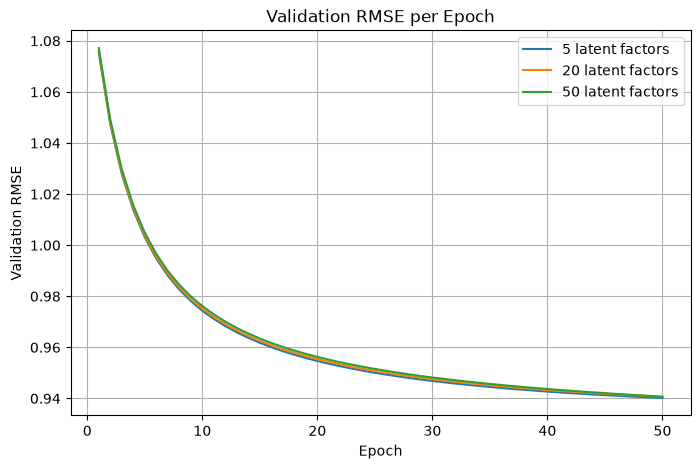

In [105]:
plt.figure(figsize=(8, 5))

for f in factor_grid:
    plt.plot(
        range(1, len(mf_hist[f]["val_rmse"]) + 1),
        mf_hist[f]["val_rmse"],
        label=f"{f} latent factors"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## FINAL COMPARISON ON TEST SET

In [108]:
results = []

t0 = time.time()
Pb = item_mean_baseline(train_pool)
results.append(evaluate("Item-mean baseline", Pb, train_pool, test_set, time.time() - t0))

t0 = time.time()
Pk = item_knn(train_pool, best_k)
results.append(evaluate(f"Item-kNN (k={best_k})", Pk, train_pool, test_set, time.time() - t0))

t0 = time.time()
mf = BiasedMF(n_factors=best_f, lr=0.001, reg=0.05, epochs=50).fit(train_pool)
Pm = mf.predict_all()
results.append(evaluate(f"Biased MF (f={best_f})", Pm, train_pool, test_set, time.time() - t0))

table = pd.DataFrame(results).set_index("Method").round(4)
table

,RMSE,MAE,P@10,R@10,NDCG@10,Fit time (s)
Method,,,,,,
Item-mean baseline,1.0210,0.8123,0.0007,0.0007,0.0007,1.2093
Item-kNN (k=150),0.9267,0.7214,0.0033,0.0029,0.0032,3.1886
Biased MF (f=5),0.9428,0.7453,0.0675,0.0457,0.0731,66.0540


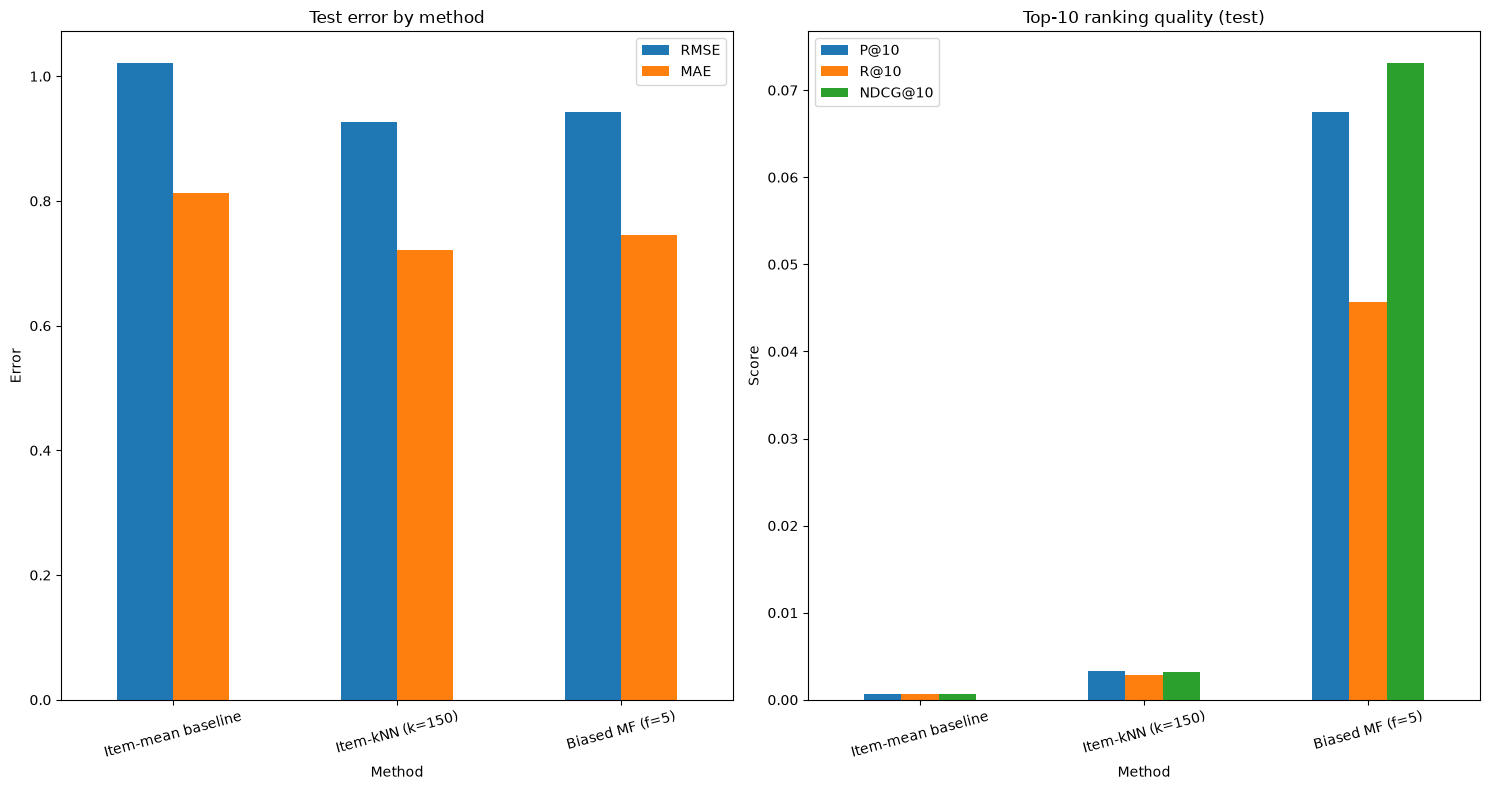

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

table[["RMSE", "MAE"]].plot.bar(ax=ax[0],rot=15,title="Test error by method")

ax[0].set_ylabel("Error")

table[["P@10", "R@10", "NDCG@10"]].plot.bar(ax=ax[1],rot=15,title="Top-10 ranking quality (test)")

ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

## Conclusion

**Results.** On the held-out test set, item-kNN (k=150) achieved the best rating-prediction accuracy, with the lowest RMSE (0.9267) and MAE (0.7214) among all three methods — outperforming both biased matrix factorization (RMSE 0.9428, MAE 0.7453) and the item-mean baseline (RMSE 1.0210, MAE 0.8123). Once both methods are fairly trained on the same `train_pool` data, item-kNN's neighborhood-weighted predictions generalize slightly better than MF's learned latent factors for this dataset and hyperparameter setting.

The story reverses sharply for ranking quality. MF achieved P@10 = 0.0675, R@10 = 0.0457, and NDCG@10 = 0.0731 — roughly 20x higher than item-kNN's P@10 = 0.0033, R@10 = 0.0029, and NDCG@10 = 0.0032, and far above the baseline's near-zero ranking scores. So despite predicting individual ratings less accurately, MF is dramatically better at correctly ordering which unseen items a user would actually prefer.

**Why the two metrics disagree.** RMSE/MAE measure how close a predicted rating is to the true rating on average, while P@K/R@K/NDCG@K measure whether the *relative ordering* of items is correct. Item-kNN's predictions for most unseen items fall back toward the item mean whenever a user has too little overlap with an item's top-k neighbors, which is common given ~94% sparsity — this produces accurate-on-average but poorly separated scores, since many items end up with nearly identical predicted values for a given user. That's fine for RMSE (average error stays low) but bad for ranking (ties and near-ties dominate the top-10). MF instead assigns every user-item pair a distinct score from `p_u · q_i`, giving much better score separation between items, which directly benefits ranking even though its average rating error is slightly higher here.

**Fit time.** kNN fit in ~3.2s versus MF's ~66s — over 20x faster, dominated by MF's per-rating SGD loop across 50 epochs.

**When to prefer which method:**
- **Item-kNN** is preferable when the goal is accurate rating prediction itself, low retraining cost, or interpretability ("recommended because it's similar to items you rated highly").
- **Matrix factorization** is preferable when the actual goal is producing a good top-N recommendation list, which is the dominant real-world use case — it generalizes far better from sparse interaction data by learning latent taste dimensions instead of relying on direct item co-occurrence.

**Limitations.** Single random split, only three latent-factor values tested (5, 20, 50, with minimal difference between them), and the ranking evaluation treats items a user never rated as automatically non-relevant, which slightly understates recall for all three methods.

This result — item-kNN edging out MF on RMSE — differs from many published comparisons where MF typically wins on both rating-prediction and ranking metrics. A plausible explanation is that MF was tuned over only three latent-factor values with fixed learning rate, regularization, and epoch count, while item-kNN was tuned over a much finer sweep of 15 values of *k*, likely leaving MF relatively under-tuned by comparison.